In [1]:
# Retail Sales & Profit Prediction using Machine Learning

# Step 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Step 2: Load Dataset
df = pd.read_csv('Superstore Dataset.csv', encoding='latin1')

# Display first 5 rows
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [3]:
# Step 3: Understand the Dataset

print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(9994, 21)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 


In [4]:
# Step 4: Data Cleaning

## Check Missing Values
print(df.isnull().sum())

## Remove Missing Values
df.dropna(inplace=True)

## Remove Duplicate Rows
df.drop_duplicates(inplace=True)

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [5]:
# Step 5: Convert Date Columns

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [6]:
# Step 6: Feature Engineering

## Extract Year, Month, Day
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Day'] = df['Order Date'].dt.day

## Calculate Profit Margin
df['Profit Margin'] = df['Profit'] / df['Sales']

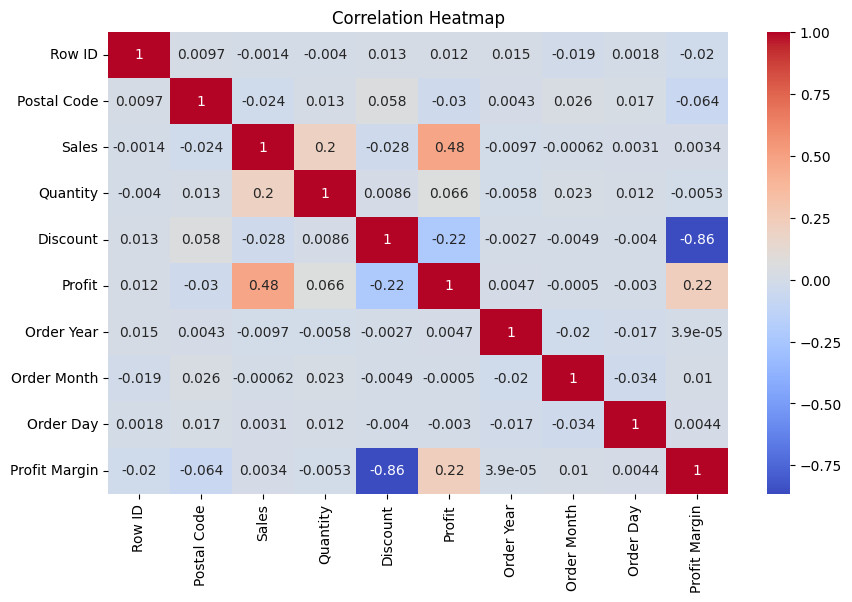

In [7]:
# Step 7: Exploratory Data Analysis (EDA)

## Correlation Heatmap
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

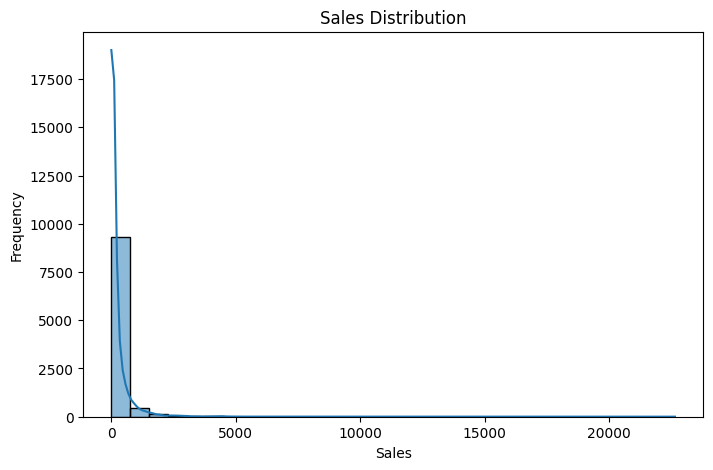

In [8]:
## Sales Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=30, kde=True)

plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

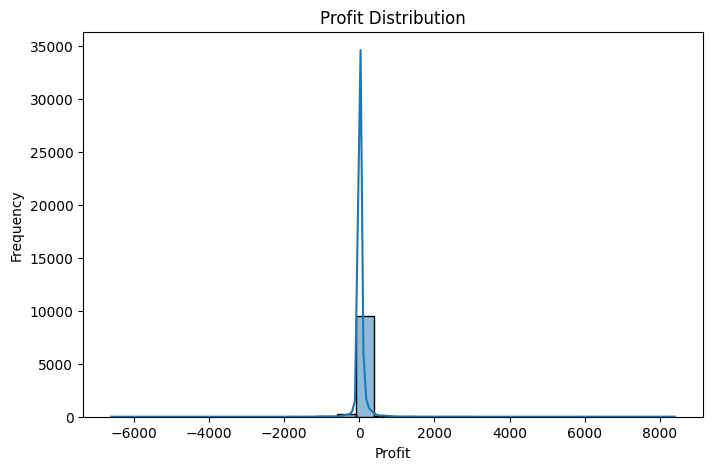

In [9]:
## Profit Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['Profit'], bins=30, kde=True)

plt.title('Profit Distribution')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.show()

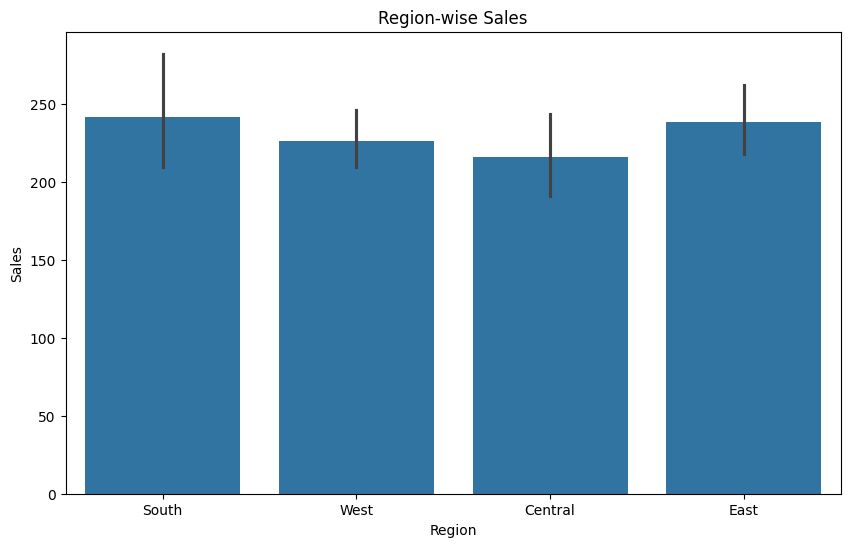

In [10]:
## Region-wise Sales Analysis

plt.figure(figsize=(10,6))
sns.barplot(x='Region', y='Sales', data=df)

plt.title('Region-wise Sales')
plt.show()

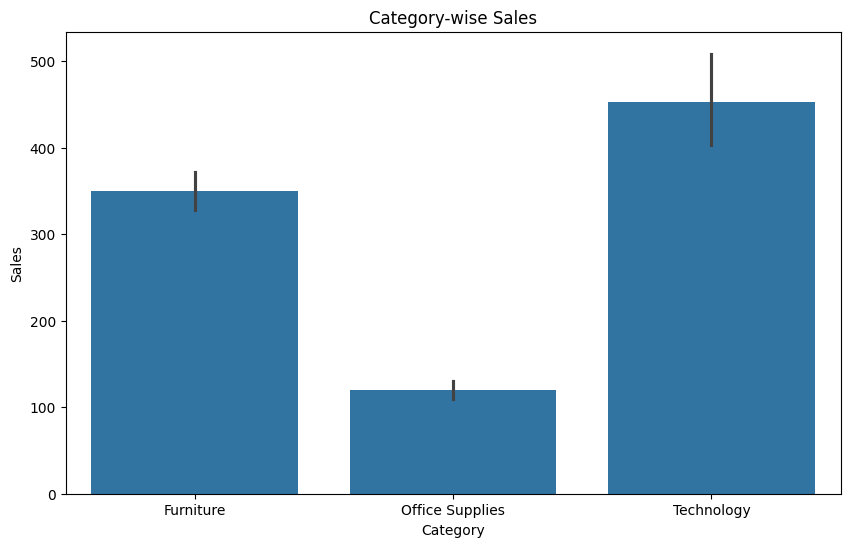

In [11]:
## Category-wise Sales

plt.figure(figsize=(10,6))
sns.barplot(x='Category', y='Sales', data=df)

plt.title('Category-wise Sales')
plt.show()

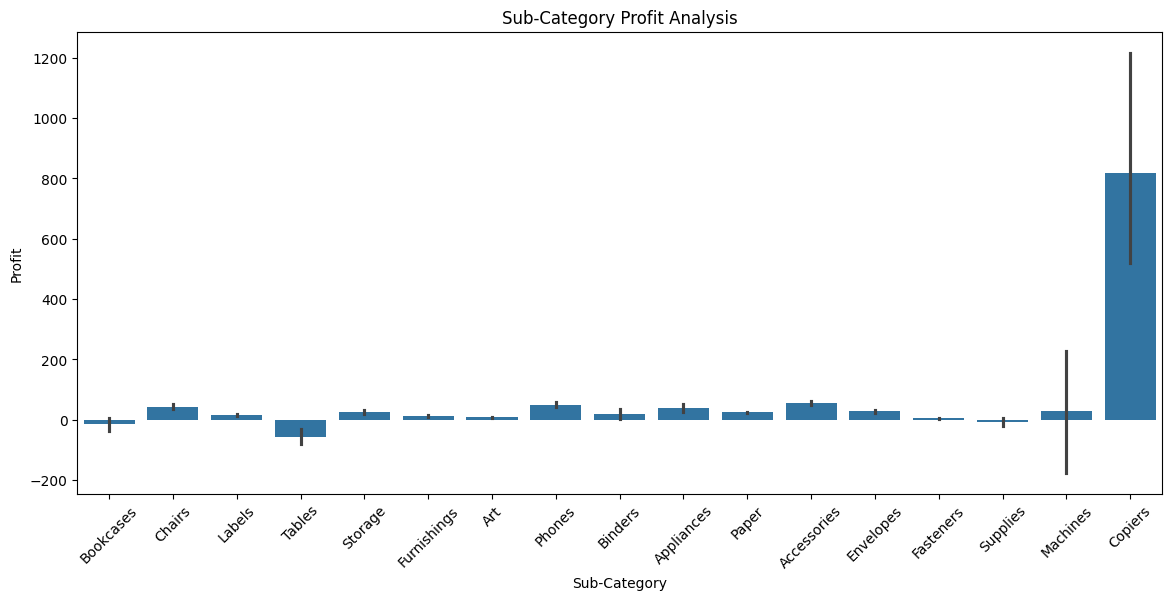

In [12]:
## Sub-Category Profit Analysis

plt.figure(figsize=(14,6))
sns.barplot(x='Sub-Category', y='Profit', data=df)

plt.xticks(rotation=45)
plt.title('Sub-Category Profit Analysis')
plt.show()

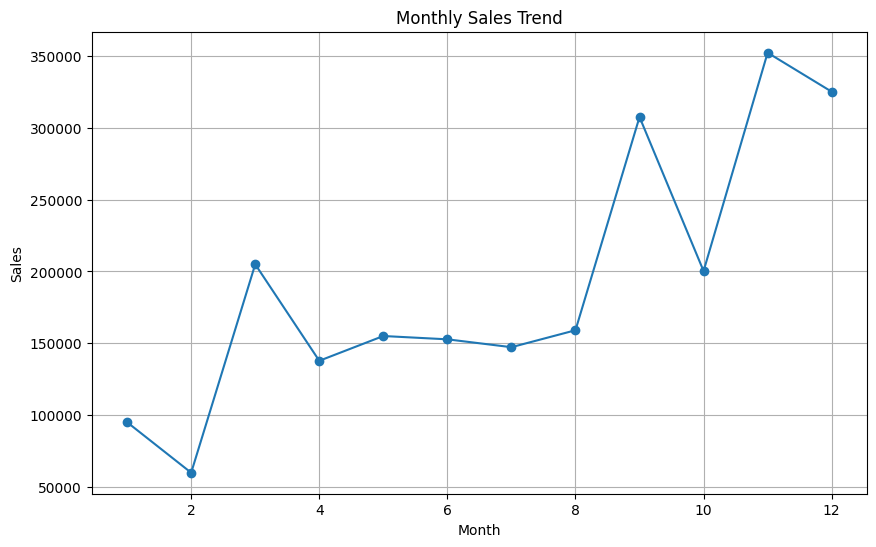

In [13]:
## Monthly Sales Trend

monthly_sales = df.groupby('Order Month')['Sales'].sum()
plt.figure(figsize=(10,6))
monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

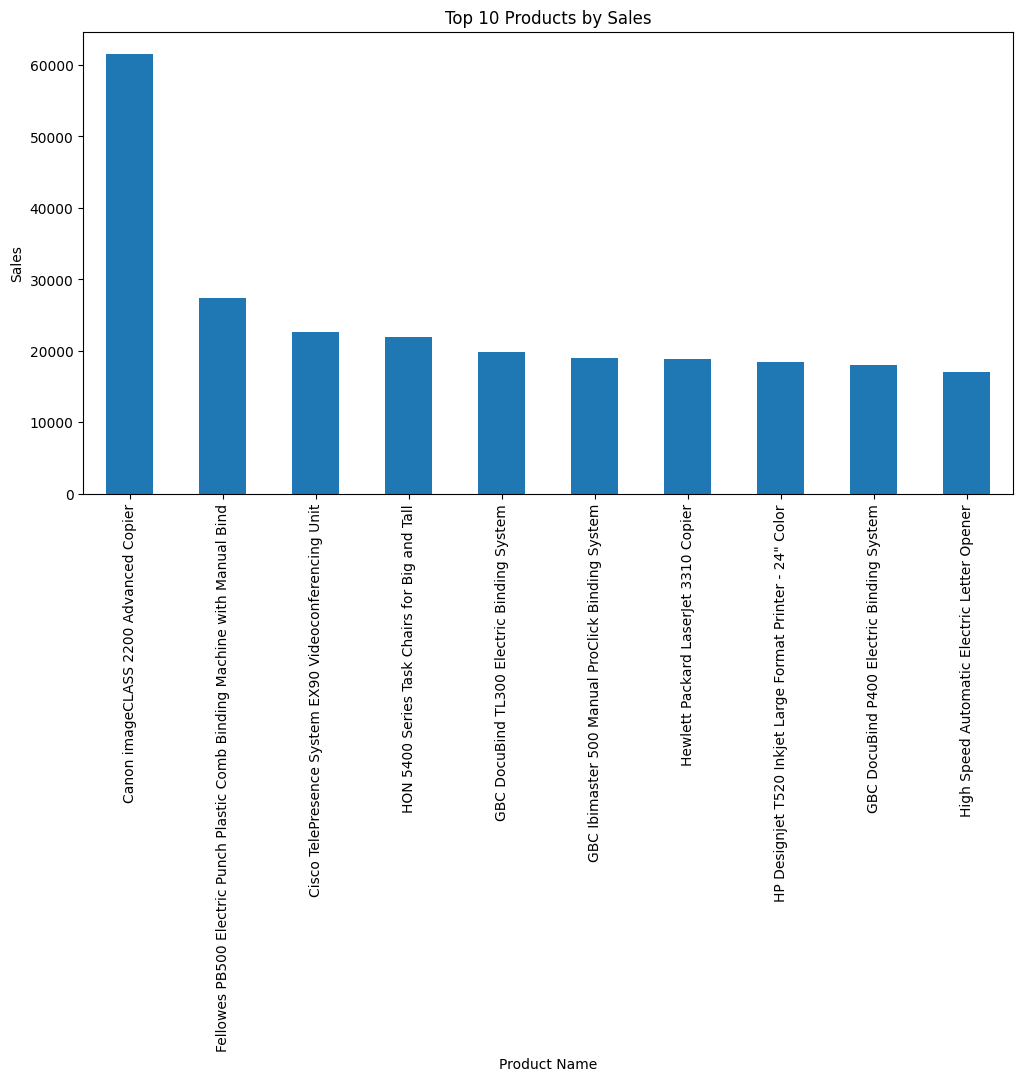

In [14]:
## Top 10 Products by Sales

top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
top_products.plot(kind='bar')

plt.title('Top 10 Products by Sales')
plt.ylabel('Sales')
plt.show()

In [15]:
# Step 8: Encode Categorical Variables

label_encoder = LabelEncoder()
categorical_columns = ['Ship Mode', 'Segment', 'Country', 'City',
                       'State', 'Region', 'Category', 'Sub-Category']

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

In [16]:
# Step 9: Select Features and Target

## Features
X = df[['Quantity', 'Discount', 'Profit', 'Order Year',
        'Order Month', 'Category', 'Sub-Category', 'Region']]

## Target Variable
y = df['Sales']

In [17]:
# Step 10: Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
# Step 11: Train Linear Regression Model

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [19]:
# Step 12: Make Predictions

lr_predictions = lr_model.predict(X_test)

In [20]:
# Step 13: Evaluate Linear Regression Model

## RMSE Formula
rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
print('RMSE:', rmse)

## R2 Score
r2 = r2_score(y_test, lr_predictions)
print('R2 Score:', r2)

RMSE: 821.9285130336104
R2 Score: -0.1436726561937316


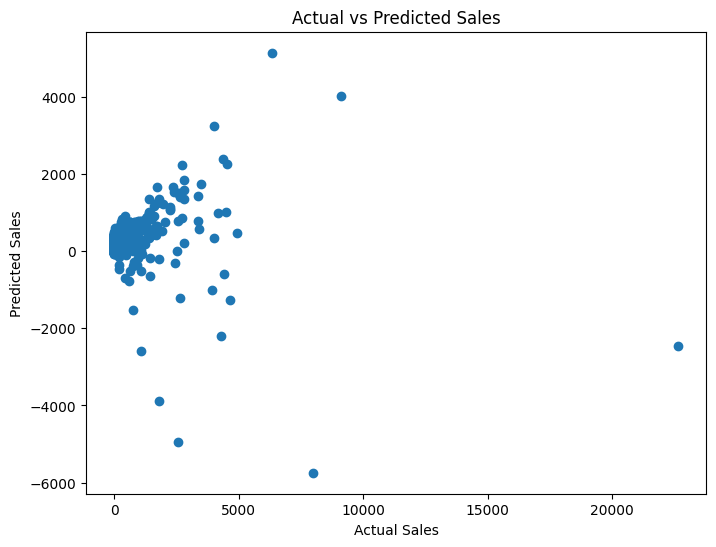

In [21]:
# Step 14: Actual vs Predicted Visualization

plt.figure(figsize=(8,6))
plt.scatter(y_test, lr_predictions)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()

In [22]:
# Step 15: Random Forest Regressor

## Train Model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [23]:
## Predictions

rf_predictions = rf_model.predict(X_test)

In [24]:
## Evaluate Random Forest

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print('Random Forest RMSE:', rf_rmse)
print('Random Forest R2 Score:', rf_r2)

Random Forest RMSE: 485.6194754747877
Random Forest R2 Score: 0.6007675483401738


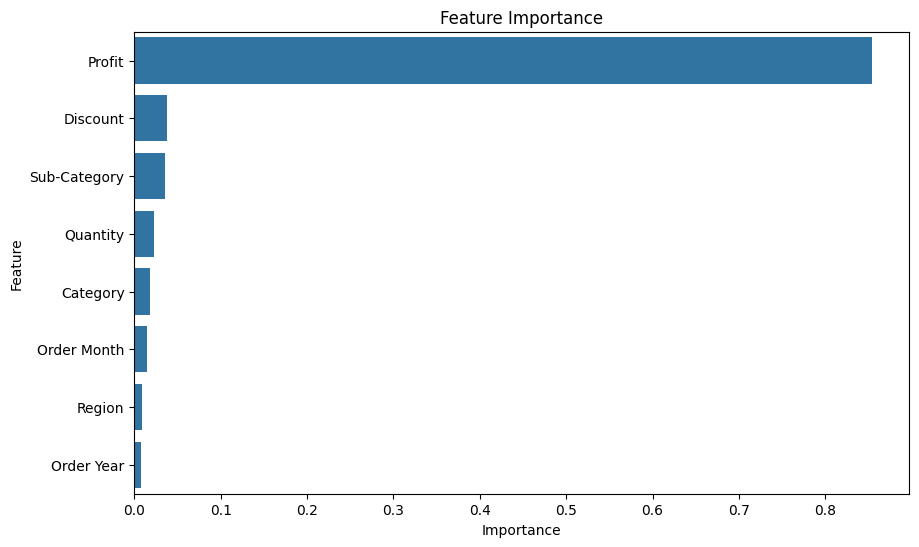

In [25]:
# Step 16: Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Feature Importance')
plt.show()

In [26]:
# Step 17: Save Cleaned Dataset (Optional)

df.to_csv('cleaned_superstore_data.csv', index=False)

In [27]:
# Step 18: Save Machine Learning Model (Optional)

import joblib
joblib.dump(rf_model, 'sales_prediction_model.pkl')

['sales_prediction_model.pkl']